# Predict Then Inpaint

This notebook loads trained highlight detection and highlight removal checkpoints, predicts highlights from an input image, converts that prediction into a hole mask, and then inpaints from the predicted mask.

In [12]:
import sys
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset

repo_root = Path.cwd()
sh_models_path = repo_root / "sh_models"
if str(sh_models_path) not in sys.path:
    sys.path.insert(0, str(sh_models_path))

from pipeline import PSDloader as psd_loader
from sh_models import highlight_detector as hd
from sh_models import pconvAE as pc_hr

three_channel_unet = importlib.import_module("3chanelunet")
prepo_pd_resnet = importlib.import_module("prepo.models.pd_resnet")

diffuse_images = str(repo_root / "data/train/can/diffuse")
specular_images = str(repo_root / "data/train/can/glossy")

dataset, loader = psd_loader.make_psd_dataloader(
    diffuse_dir=diffuse_images,
    specular_dir=specular_images,
    batch_size=4,
    shuffle=False,
    threshold_method="quantile",
    threshold=0.95,
    kernel_size=3,
    soft_gamma=0.5,
)

sample_index = 6 if len(dataset) > 6 else 0
small_dataset = Subset(dataset, [sample_index])
device = "cuda" if torch.cuda.is_available() else "cpu"
weights_dir = repo_root / "weights"


In [13]:
def _dilate_binary_mask(mask, kernel_size=3):
    if kernel_size <= 1:
        return mask
    pad = kernel_size // 2
    return F.max_pool2d(mask, kernel_size=kernel_size, stride=1, padding=pad)


def _masked_mean(pixel_values, mask, eps=1e-8):
    if mask.shape[1] != 1:
        mask = mask.mean(dim=1, keepdim=True)
    denom = mask.sum() * pixel_values.shape[1]
    return (pixel_values * mask).sum() / (denom + eps)


def _detector_logits_to_non_highlight_prob(logits, detector_mode):
    if detector_mode == "legacy_forward":
        return logits
    if logits.ndim != 4 or logits.shape[1] != 2:
        raise ValueError(f"Expected logits with shape (B,2,H,W), got {tuple(logits.shape)}")
    if detector_mode == "soft_bce":
        return torch.sigmoid(logits[:, 1:2] - logits[:, 0:1])
    if detector_mode == "mask_ce_dice":
        return torch.softmax(logits, dim=1)[:, 1:2]
    raise ValueError("detector_mode must be 'mask_ce_dice', 'soft_bce', or 'legacy_forward'")


@torch.no_grad()
def predict_highlight_detector(model, x, *, detector_mode="mask_ce_dice"):
    model.eval()
    if detector_mode == "legacy_forward":
        return model(x).clamp(0.0, 1.0)
    logits = model.get_logits(x)
    return _detector_logits_to_non_highlight_prob(logits, detector_mode)


def _forward_highlight_removal_model(model, x_masked, valid_mask, hole_mask, soft_mask=None):
    try:
        hole_pred = model(
            x_masked,
            valid_mask=valid_mask,
            hole_mask=hole_mask,
            soft_mask=soft_mask,
        )
    except TypeError:
        try:
            hole_pred = model(x_masked, valid_mask=valid_mask, hole_mask=hole_mask)
        except TypeError:
            hole_pred = model(x_masked, valid_mask)
    return hole_pred


class _PDResNetDecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        fused_channels = out_channels + skip_channels
        self.fuse = nn.Sequential(
            nn.Conv2d(fused_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.fuse(x)


class PrepoPDResNetReconstructor(nn.Module):
    def __init__(self, out_channels=3):
        super().__init__()
        self.backbone = prepo_pd_resnet.pdresnet18(pretrained=False, num_classes=out_channels)
        self.dec4 = _PDResNetDecoderBlock(512, 256, 256)
        self.dec3 = _PDResNetDecoderBlock(256, 128, 128)
        self.dec2 = _PDResNetDecoderBlock(128, 64, 64)
        self.dec1 = _PDResNetDecoderBlock(64, 64, 64)
        self.dec0 = _PDResNetDecoderBlock(64, 0, 32)
        self.out = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x, valid_mask=None, hole_mask=None):
        if valid_mask is None:
            raise ValueError("PrepoPDResNetReconstructor requires a validity mask.")
        (stem, enc1, enc2, enc3, enc4), _ = self.backbone.forward_encoder(x, valid_mask)
        y = self.dec4(enc4, enc3)
        y = self.dec3(y, enc2)
        y = self.dec2(y, enc1)
        y = self.dec1(y, stem)
        y = self.dec0(y)
        if y.shape[-2:] != x.shape[-2:]:
            y = F.interpolate(y, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return self.out(y)


class ThreeChannelUNetAdapter(nn.Module):
    def __init__(
        self,
        *,
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        num_heads=4,
        use_bottleneck_self_attention=True,
        use_soft_mask_input=False,
    ):
        super().__init__()
        self.use_soft_mask_input = use_soft_mask_input
        self.model = three_channel_unet.UNet(
            in_channels=in_channels + (1 if use_soft_mask_input else 0),
            base_channels=base_channels,
            depth=depth,
            out_channels=out_channels,
            Attention=(three_channel_unet.TransformerEncoderSA if use_bottleneck_self_attention else None),
            OnlyonBottleneck=use_bottleneck_self_attention,
            num_heads=num_heads,
            bottleneck_length=bottleneck_length,
        )

    def forward(self, x, valid_mask=None, hole_mask=None, soft_mask=None):
        if self.use_soft_mask_input:
            if soft_mask is None:
                raise ValueError("ThreeChannelUNetAdapter with use_soft_mask_input=True requires soft_mask.")
            corruption_map = 1.0 - soft_mask
            x = torch.cat([x, corruption_map], dim=1)
        return self.model(x)


def load_trained_highlight_detector(detector_ckpt_path, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(detector_ckpt_path, map_location="cpu")
    config = ckpt.get("config", {})
    model = hd.Detector(in_channels=config.get("in_channels", 3))
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device)
    model.eval()
    detector_mode = config.get("detector_mode")
    if detector_mode is None:
        detector_mode = "legacy_forward" if config.get("loss_name") == "l1" else "soft_bce"
    return model, detector_mode, ckpt


def load_trained_removal_model(removal_ckpt_path, *, removal_arch="unet4", device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(removal_ckpt_path, map_location="cpu")
    if removal_arch == "autoencoder":
        cfg = ckpt.get("config", {})
        model = pc_hr.HighlightRemovalAutoencoder(
            in_channels=cfg.get("in_channels", 3),
            out_channels=cfg.get("out_channels", 3),
            base_features=cfg.get("base_features", 64),
            depth=cfg.get("depth", 4),
            max_features=cfg.get("max_features", 512),
            bottleneck_blocks=cfg.get("bottleneck_blocks", 2),
            use_conv_shift=cfg.get("use_conv_shift", False),
        )
    elif removal_arch == "pdresnet":
        model = PrepoPDResNetReconstructor(out_channels=3)
    elif removal_arch == "unet3":
        model = ThreeChannelUNetAdapter(use_soft_mask_input=False)
    elif removal_arch == "unet4":
        model = ThreeChannelUNetAdapter(use_soft_mask_input=True)
    else:
        raise ValueError("removal_arch must be 'autoencoder', 'pdresnet', 'unet3', or 'unet4'")
    model.load_state_dict(ckpt["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model, ckpt


@torch.no_grad()
def run_detector_then_inpaint(
    sample,
    *,
    detector_ckpt_path,
    removal_ckpt_path,
    removal_arch="unet4",
    detector_name=None,
    removal_name=None,
    device=None,
    valid_threshold=0.95,
    hole_dilate_kernel=3,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    detector_model, detector_mode, _ = load_trained_highlight_detector(detector_ckpt_path, device=device)
    removal_model, _ = load_trained_removal_model(removal_ckpt_path, removal_arch=removal_arch, device=device)
    x = sample["input"].unsqueeze(0).to(device).float()
    y_true = sample.get("target")
    if torch.is_tensor(y_true):
        y_true = y_true.unsqueeze(0).to(device).float()
    pred_soft_mask = predict_highlight_detector(detector_model, x, detector_mode=detector_mode).clamp(0.0, 1.0)
    valid_mask = (pred_soft_mask >= valid_threshold).float()
    hole_mask = 1.0 - valid_mask
    if hole_dilate_kernel > 1:
        hole_mask = (_dilate_binary_mask(hole_mask, kernel_size=hole_dilate_kernel) > 0).float()
        valid_mask = 1.0 - hole_mask
    x_masked = x * valid_mask
    hole_pred = _forward_highlight_removal_model(removal_model, x_masked, valid_mask, hole_mask, soft_mask=pred_soft_mask)
    y_pred = x * valid_mask + hole_pred * hole_mask
    result = {
        "name": sample.get("name", "sample"),
        "detector_name": detector_name or Path(detector_ckpt_path).stem,
        "removal_name": removal_name or Path(removal_ckpt_path).stem,
        "detector_mode": detector_mode,
        "detector_ckpt_path": str(detector_ckpt_path),
        "removal_ckpt_path": str(removal_ckpt_path),
        "removal_arch": removal_arch,
        "x": x,
        "y_true": y_true,
        "pred_soft_mask": pred_soft_mask,
        "valid_mask": valid_mask,
        "hole_mask": hole_mask,
        "x_masked": x_masked,
        "hole_pred": hole_pred,
        "y_pred": y_pred,
    }
    if y_true is not None:
        abs_err = (y_pred - y_true).abs()
        result["hole_mae"] = _masked_mean(abs_err, hole_mask).item()
    return result


@torch.no_grad()
def show_detector_then_inpaint(result):
    x = result["x"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
    x_masked = result["x_masked"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
    pred_highlight = (1.0 - result["pred_soft_mask"][0, 0].detach().cpu()).clamp(0, 1)
    hole_mask = result["hole_mask"][0, 0].detach().cpu()
    y_pred = result["y_pred"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
    y_true = result.get("y_true")
    if y_true is not None:
        abs_err = (result["y_pred"][0].detach().cpu() - result["y_true"][0].detach().cpu()).abs().mean(dim=0)
        fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    else:
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    axes[0].imshow(x)
    axes[0].set_title(f"Input\n{result['name']}")
    axes[0].axis("off")
    axes[1].imshow(pred_highlight, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Predicted highlight\n1 - soft_mask")
    axes[1].axis("off")
    axes[2].imshow(hole_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Predicted hole mask")
    axes[2].axis("off")
    axes[3].imshow(x_masked)
    axes[3].set_title("Masked input")
    axes[3].axis("off")
    axes[4].imshow(y_pred)
    axes[4].set_title("Inpainted output")
    axes[4].axis("off")
    if y_true is not None:
        axes[5].imshow(abs_err, cmap="gray", vmin=0, vmax=1)
        axes[5].set_title("Mean abs error")
        axes[5].axis("off")
    plt.tight_layout()
    plt.show()
    if y_true is not None:
        print(f"hole_mae: {result['hole_mae']:.6f}")
    print(f"detector: {result['detector_name']} ({result['detector_mode']})")
    print(f"removal: {result['removal_name']} ({result['removal_arch']})")


DETECTOR_SPECS = [
    {"name": "soft_bce", "ckpt_path": weights_dir / "best_detector_soft_bce.pth"},
]


REMOVAL_SPECS = [
    {"name": "autoencoder", "ckpt_path": weights_dir / "best_highlight_removal_rgb.pth", "arch": "autoencoder"},
    {"name": "pdresnet", "ckpt_path": weights_dir / "prepo_pdresnet_rgb.pth", "arch": "pdresnet"},
    {"name": "unet3_self_attention", "ckpt_path": weights_dir / "3channel_unet_bottleneck_self_attention_rgb.pth", "arch": "unet3"},
    {"name": "unet4_softmask_input", "ckpt_path": weights_dir / "3channel_unet_bottleneck_self_attention_softmask_rgb.pth", "arch": "unet4"},
]


@torch.no_grad()
def run_all_detector_remover_combinations(sample, *, detector_specs, removal_specs, device=None, valid_threshold=0.95, hole_dilate_kernel=3):
    results = []
    for detector_spec in detector_specs:
        for removal_spec in removal_specs:
            results.append(
                run_detector_then_inpaint(
                    sample,
                    detector_ckpt_path=str(detector_spec["ckpt_path"]),
                    removal_ckpt_path=str(removal_spec["ckpt_path"]),
                    removal_arch=removal_spec["arch"],
                    detector_name=detector_spec["name"],
                    removal_name=removal_spec["name"],
                    device=device,
                    valid_threshold=valid_threshold,
                    hole_dilate_kernel=hole_dilate_kernel,
                )
            )
    return results


def print_pipeline_summary(results):
    rows = []
    for result in results:
        rows.append((result["detector_name"], result["detector_mode"], result["removal_name"], result["removal_arch"], result.get("hole_mae", float("nan"))))
    rows.sort(key=lambda row: row[4])
    header = f"{'detector':<24} {'mode':<16} {'removal':<24} {'arch':<14} {'hole_mae':>10}"
    print(header)
    print("-" * len(header))
    for detector_name, detector_mode, removal_name, removal_arch, hole_mae in rows:
        print(f"{detector_name:<24} {detector_mode:<16} {removal_name:<24} {removal_arch:<14} {hole_mae:>10.6f}")


def show_pipeline_grid(results, detector_specs, removal_specs):
    result_lookup = {(result['detector_name'], result['removal_name']): result for result in results}
    n_rows = len(detector_specs)
    n_cols = len(removal_specs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [list(axes)]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]
    for row, detector_spec in enumerate(detector_specs):
        for col, removal_spec in enumerate(removal_specs):
            ax = axes[row][col]
            result = result_lookup[(detector_spec['name'], removal_spec['name'])]
            pred = result['y_pred'][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
            ax.imshow(pred)
            title = f"{removal_spec['name']}\nMAE {result['hole_mae']:.4f}"
            ax.set_title(title if row == 0 else f"MAE {result['hole_mae']:.4f}")
            if col == 0:
                ax.set_ylabel(detector_spec['name'])
            ax.axis('off')
    plt.tight_layout()
    plt.show()


def select_pipeline_result(results, detector_name, removal_name):
    for result in results:
        if result['detector_name'] == detector_name and result['removal_name'] == removal_name:
            return result
    raise KeyError(f"No result for detector={detector_name}, removal={removal_name}")


detector                 mode             removal                  arch             hole_mae
--------------------------------------------------------------------------------------------
soft_bce                 soft_bce         pdresnet                 pdresnet         0.013415
soft_bce                 soft_bce         unet3_self_attention     unet3            0.015757
soft_bce                 soft_bce         unet4_softmask_input     unet4            0.018184
soft_bce                 soft_bce         autoencoder              autoencoder      0.037624


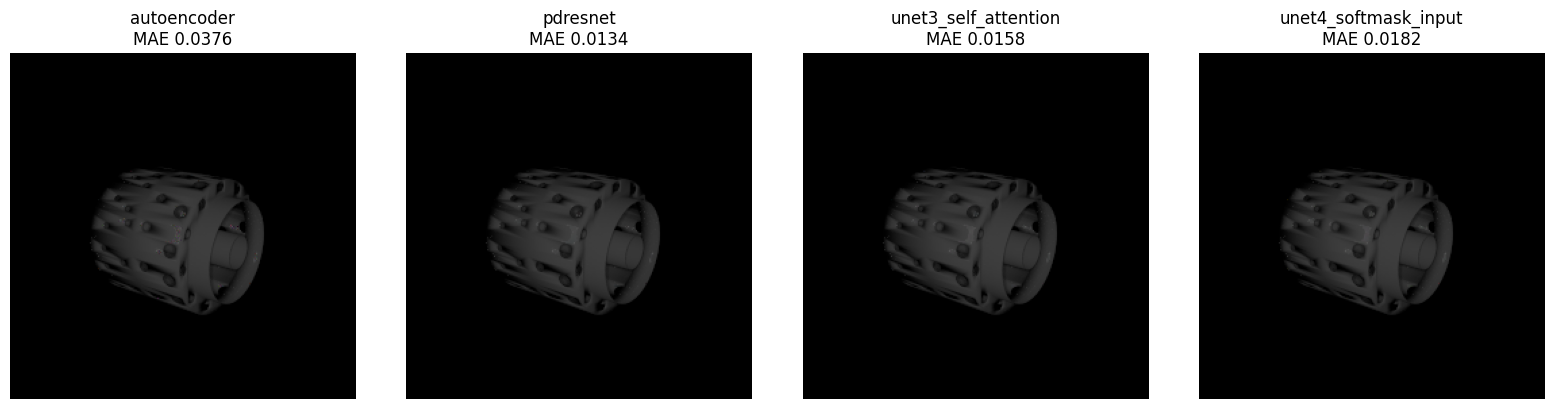

In [ ]:
# Run every trained detector with every trained inpainting model on the current test sample.

all_pipeline_results = run_all_detector_remover_combinations(
    sample=small_dataset[0],
    detector_specs=DETECTOR_SPECS,
    removal_specs=REMOVAL_SPECS,
    device=device,
    valid_threshold=0.95,
    hole_dilate_kernel=1,
)

#print_pipeline_summary(all_pipeline_results)
show_pipeline_grid(all_pipeline_results, DETECTOR_SPECS, REMOVAL_SPECS)


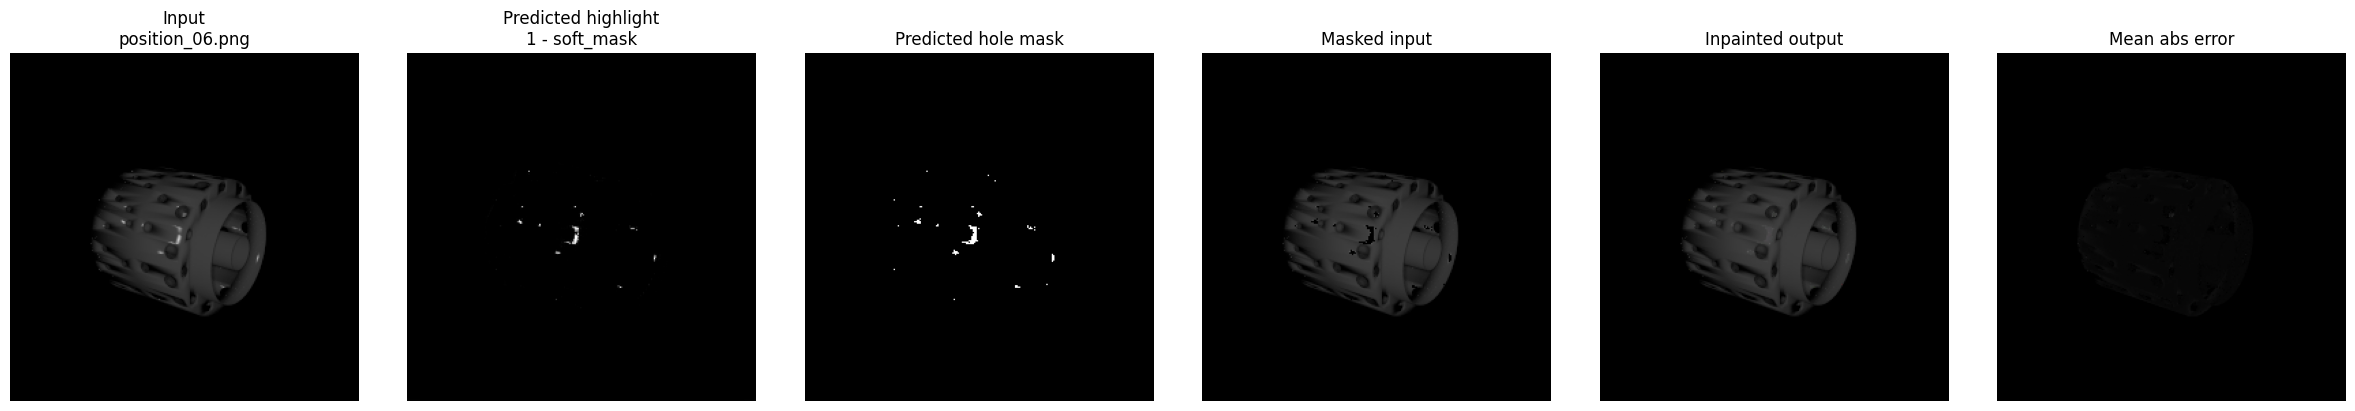

hole_mae: 0.018184
detector: soft_bce (soft_bce)
removal: unet4_softmask_input (unet4)


In [15]:
# Inspect one specific detector-remover pair in detail.
# Change detector_name and removal_name to any pair listed in the summary above.

detector_name = "soft_bce"
removal_name = "unet4_softmask_input"

selected_result = select_pipeline_result(all_pipeline_results, detector_name, removal_name)
show_detector_then_inpaint(selected_result)
